In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("/content/cleaned_dataset_for_data_analytics.xlsx")

In [4]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,CalculatedTotal
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,2504.04


In [5]:
df.shape

(1200, 15)

In [6]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,CalculatedTotal
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300,1053.968300
std,1.407557,197.177146,2.281983,819.856558,819.856558
min,1.000000,11.390000,1.000000,11.390000,11.390000
25%,2.000000,186.062500,4.000000,410.520000,410.520000
50%,3.000000,364.210000,5.000000,823.615000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000,3456.400000


In [7]:
df.isnull().sum()

,0
OrderID,0
Date,0
CustomerID,0
Product,0
Quantity,0
UnitPrice,0
ShippingAddress,0
PaymentMethod,0
OrderStatus,0
TrackingNumber,0


In [14]:
df['TotalPrice'].sum()

np.float64(1264761.96)

In [15]:
df['TotalPrice'].mean()

np.float64(1053.9683)

In [16]:
df['TotalPrice'].max()

3456.4

In [17]:
df['TotalPrice'].max()

3456.4

In [18]:
df['Product'].value_counts()

,count
Product,
Printer,181
Tablet,179
Chair,178
Laptop,173
Desk,170
Monitor,163
Phone,156


In [19]:
df['PaymentMethod'].value_counts()

,count
PaymentMethod,
Online,258
Cash,246
Credit Card,234
Debit Card,232
Gift Card,230


In [20]:
df['OrderStatus'].value_counts()

,count
OrderStatus,
Cancelled,250
Returned,247
Pending,237
Shipped,235
Delivered,231


In [21]:
df['ReferralSource'].value_counts()

,count
ReferralSource,
Instagram,259
Email,250
Google,241
Facebook,228
Referral,222


In [22]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['TotalPrice'].sum()

monthly_sales

,TotalPrice
Month,
1,124313.23
2,112344.78
3,123840.93
4,109186.05
5,135142.59
6,170616.13
7,85784.64
8,86343.21
9,69321.65


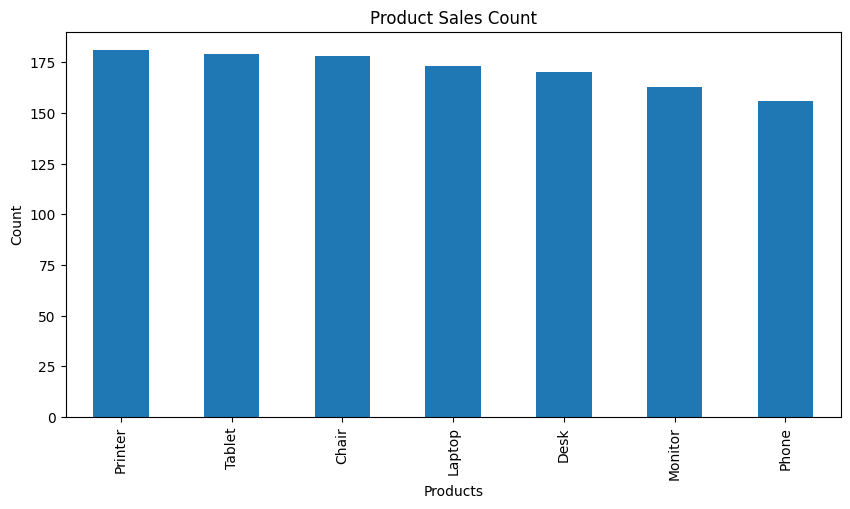

In [23]:
df['Product'].value_counts().plot(kind='bar', figsize=(10,5))

plt.title("Product Sales Count")
plt.xlabel("Products")
plt.ylabel("Count")

plt.show()

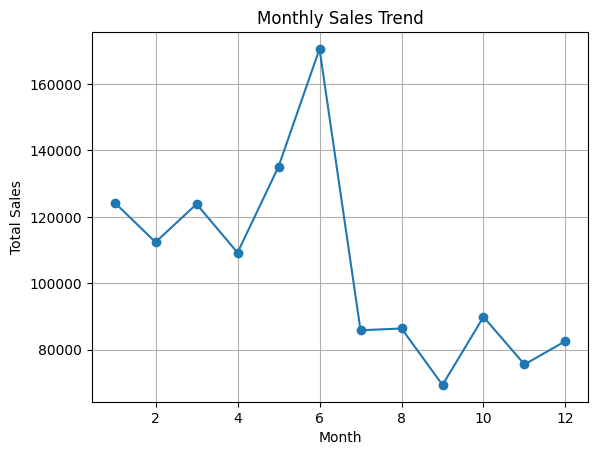

In [24]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(True)

plt.show()

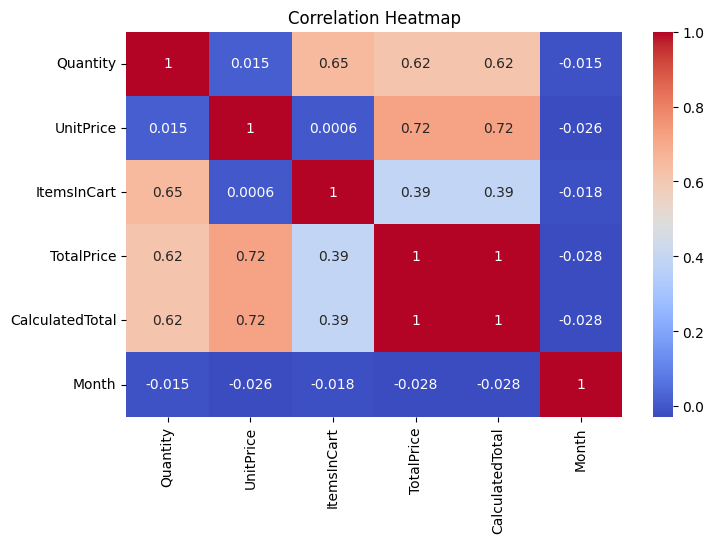

In [29]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,5))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

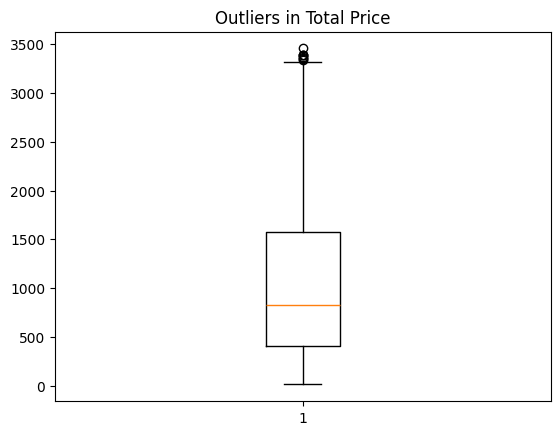

In [30]:
plt.boxplot(df['TotalPrice'])

plt.title("Outliers in Total Price")

plt.show()

In [31]:
df[['OrderID', 'Product', 'TotalPrice']].sort_values(by='TotalPrice', ascending=False).head()

,OrderID,Product,TotalPrice
789,ORD200789,Tablet,3456.40
1122,ORD201122,Monitor,3390.95
632,ORD200632,Laptop,3390.80
469,ORD200469,Chair,3384.90
328,ORD200328,Tablet,3370.20
